# Data Understanding & Data Preparation

Langkah ini bertujuan untuk mengevaluasi kualitas data mentah (raw data) audio. Melalui visualisasi sinyal suara, kita dapat mengidentifikasi karakteristik akustik yang dihasilkan serta mendeteksi keberadaan noise atau gangguan frekuensi yang tidak diinginkan pada suara kambing. Dengan membedah data mentah ini, kita dapat memastikan apakah sinyal suara murni tetap terjaga atau terkontaminasi oleh suara latar belakang.

## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive/RawDataset"

normal_dir = os.path.join(base_path, "Sesi_Normal")
stress_dir = os.path.join(base_path, "Sesi_Stress")

print("Jumlah file audio NORMAL :", len(os.listdir(normal_dir)))
print("Jumlah file audio STRESS :", len(os.listdir(stress_dir)))

Jumlah file audio NORMAL : 15
Jumlah file audio STRESS : 17


## Import Library

In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

##Load File Audio

In [ ]:
# Path ke file normal m4a
normal_path = "/content/drive/MyDrive/RawDataset/Sesi_Normal/"

# Menyimpan audio & sample rate
normal_audio_data = {}
normal_sample_rates = {}

# Loop membaca file m4a
for i in range(1,16):
    file_path = f"{normal_path}normal{i}.m4a"

    y_normal, sr_normal = librosa.load(file_path, sr=None)

    normal_audio_data[f"normal{i}"] = y_normal
    normal_sample_rates[f"normal{i}"] = sr_normal

    print(f"File              : normal{i}.m4a")
    print(f"Sample Rate       : {sr_normal} Hz")
    print(f"Total Samples     : {len(y_normal)}")
    print(f"Durasi Audio      : {len(y_normal)/sr_normal:.2f} detik")
    print("-"*40)

/tmp/ipykernel_2656/2013307635.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y_normal, sr_normal = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


File              : normal1.m4a
Sample Rate       : 44100 Hz
Total Samples     : 14913536
Durasi Audio      : 338.18 detik
----------------------------------------


/tmp/ipykernel_2656/2013307635.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y_normal, sr_normal = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


File              : normal2.m4a
Sample Rate       : 44100 Hz
Total Samples     : 5268480
Durasi Audio      : 119.47 detik
----------------------------------------


/tmp/ipykernel_2656/2013307635.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y_normal, sr_normal = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


...

File              : normal13.m4a
Sample Rate       : 48000 Hz
Total Samples     : 15534080
Durasi Audio      : 323.63 detik
----------------------------------------


/tmp/ipykernel_2656/2013307635.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y_normal, sr_normal = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


File              : normal14.m4a
Sample Rate       : 48000 Hz
Total Samples     : 16575488
Durasi Audio      : 345.32 detik
----------------------------------------


/tmp/ipykernel_2656/2013307635.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y_normal, sr_normal = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


File              : normal15.m4a
Sample Rate       : 48000 Hz
Total Samples     : 14556160
Durasi Audio      : 303.25 detik
----------------------------------------


In [ ]:
# Path ke file stress m4a
stress_path = "/content/drive/MyDrive/RawDataset/Sesi_Stress/"

# Menyimpan audio & sample rate
stress_audio_data = {}
stress_sample_rates = {}

# Loop membaca file m4a
for i in range(1, 18):
    file_path = f"{stress_path}stress{i}.m4a"

    y_stress, sr_stress = librosa.load(file_path, sr=None)

    stress_audio_data[f"stress{i}"] = y_stress
    stress_sample_rates[f"stress{i}"] = sr_stress

    print(f"File              : stress{i}.m4a")
    print(f"Sample Rate       : {sr_stress} Hz")
    print(f"Total Samples     : {len(y_stress)}")
    print(f"Durasi Audio      : {len(y_stress)/sr_stress:.2f} detik")
    print("-"*40)

/tmp/ipykernel_2656/2860948539.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y_stress, sr_stress = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


File              : stress1.m4a
Sample Rate       : 44100 Hz
Total Samples     : 1932288
Durasi Audio      : 43.82 detik
----------------------------------------


/tmp/ipykernel_2656/2860948539.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y_stress, sr_stress = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


File              : stress2.m4a
Sample Rate       : 44100 Hz
Total Samples     : 66269184
Durasi Audio      : 1502.70 detik
----------------------------------------


/tmp/ipykernel_2656/2860948539.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y_stress, sr_stress = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


...

File              : stress15.m4a
Sample Rate       : 48000 Hz
Total Samples     : 14863360
Durasi Audio      : 309.65 detik
----------------------------------------


/tmp/ipykernel_2656/2860948539.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y_stress, sr_stress = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


File              : stress16.m4a
Sample Rate       : 48000 Hz
Total Samples     : 11374592
Durasi Audio      : 236.97 detik
----------------------------------------


/tmp/ipykernel_2656/2860948539.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y_stress, sr_stress = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


File              : stress17.m4a
Sample Rate       : 48000 Hz
Total Samples     : 4384768
Durasi Audio      : 91.35 detik
----------------------------------------


- Audio terdiri dari ribuan titik angka

- Sample rate = jumlah data suara per detik

- Audio panjang → belum siap langsung untuk AI

## Visualisasi Waveform (Bentuk Suara)

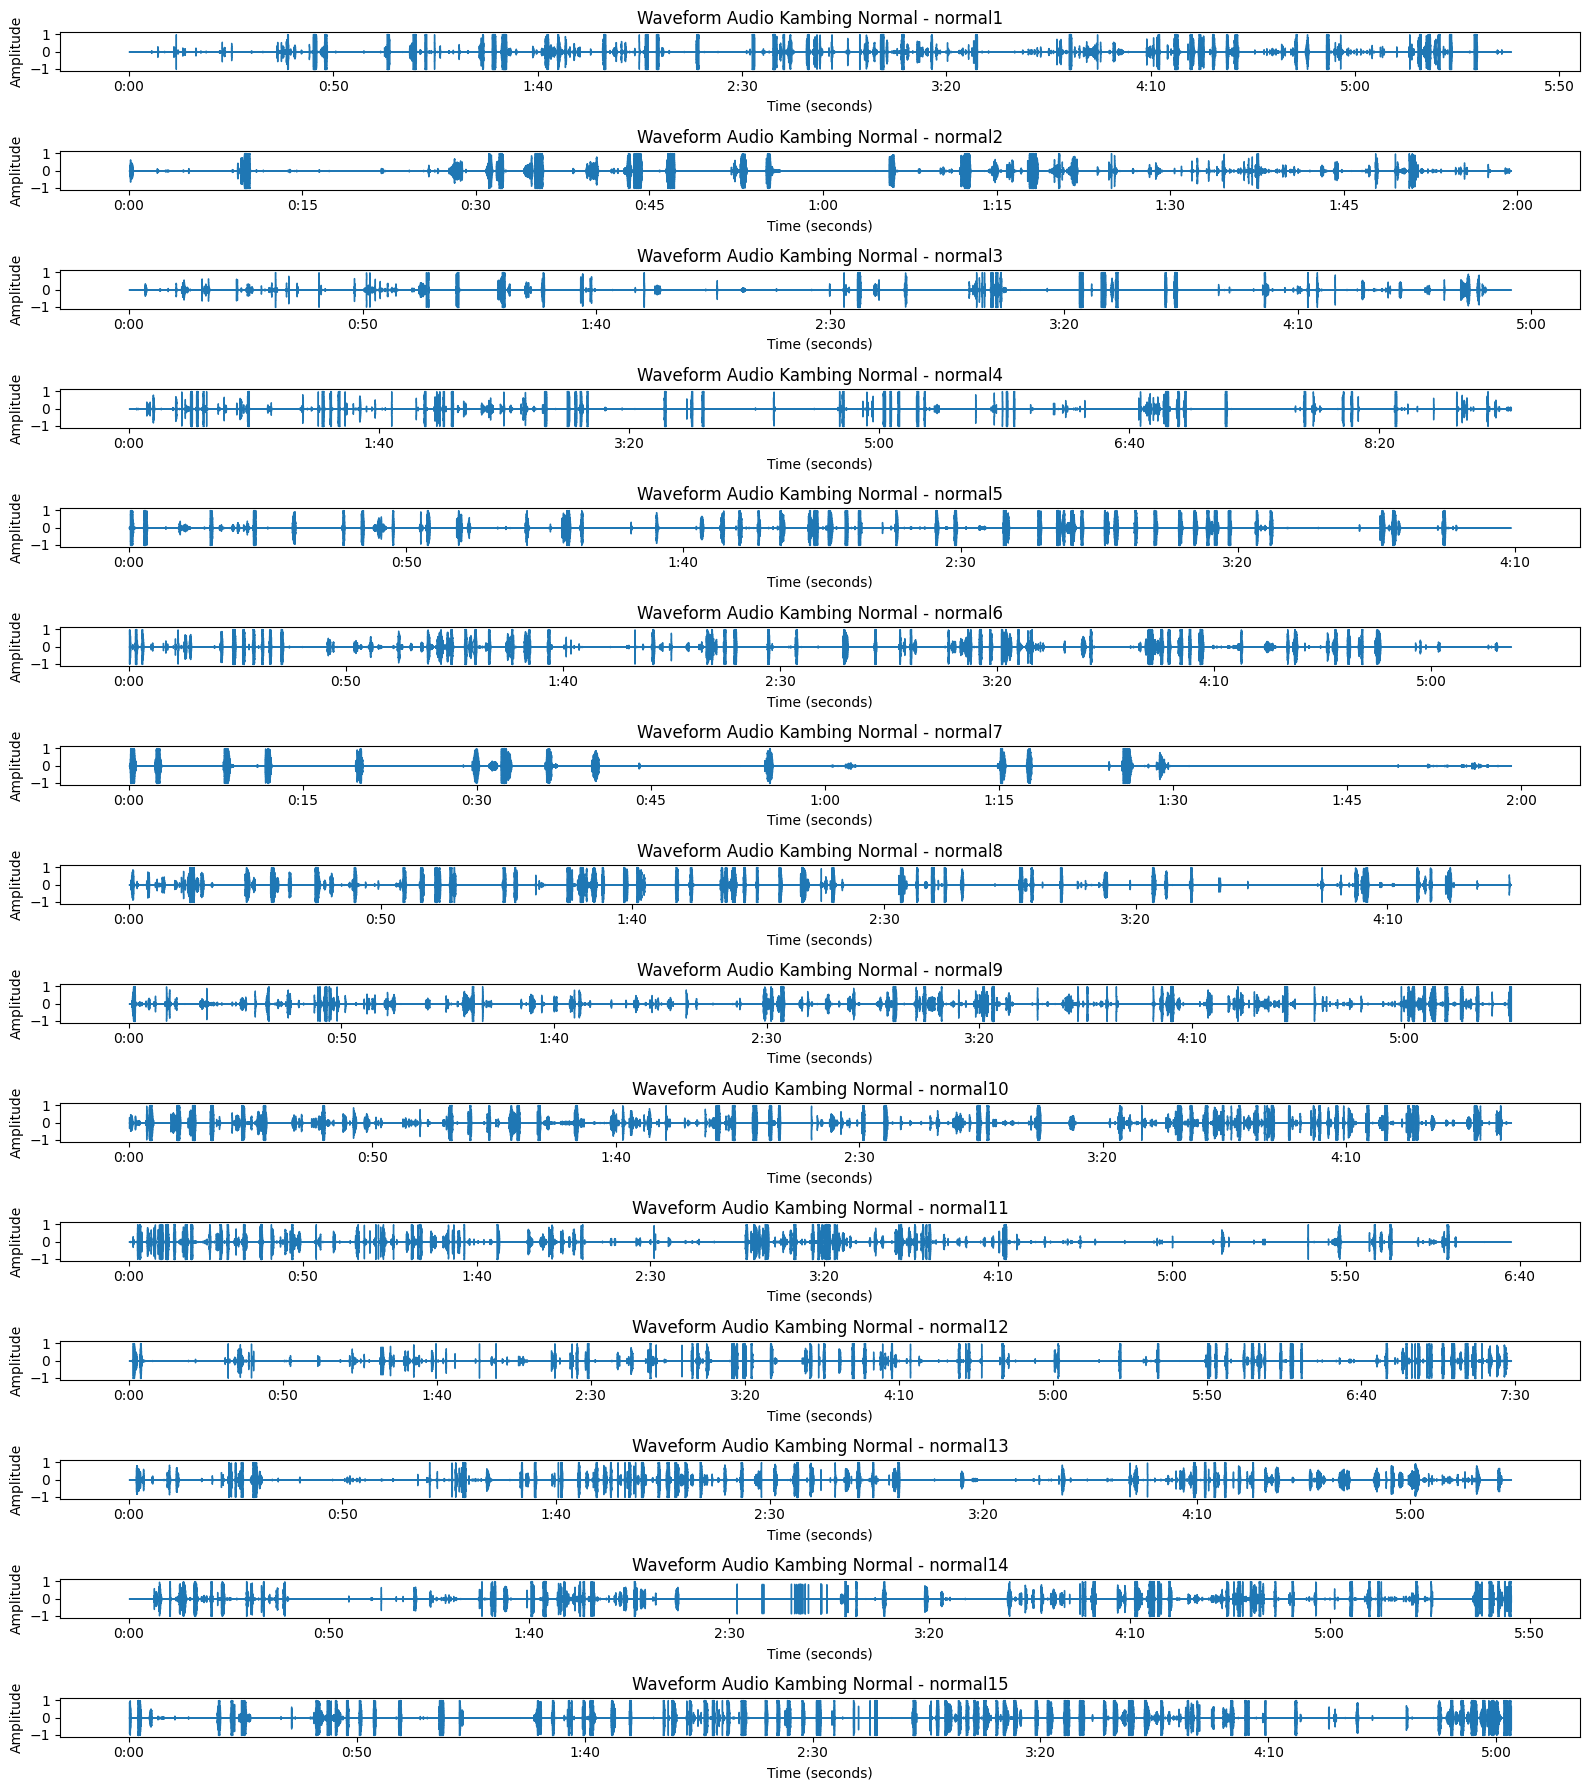

In [ ]:
plt.figure(figsize=(16, 18))

for idx, (key, y_normal) in enumerate(normal_audio_data.items(), start=1):
    sr_normal = normal_sample_rates[key]

    plt.subplot(15, 1, idx)
    librosa.display.waveshow(y_normal, sr=sr_normal)
    plt.title(f"Waveform Audio Kambing Normal - {key}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [1]:
key, y_normal = list(normal_audio_data.items())[0]
sr_normal = normal_sample_rates[key]

plt.figure(figsize=(12, 4))

librosa.display.waveshow(y_normal, sr=sr_normal)
plt.title(f"Waveform Audio Kambing Normal - {key}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

NameError: name 'normal_audio_data' is not defined

In [ ]:
plt.figure(figsize=(16, 18))

for idx, (key, y_normal) in enumerate(normal_audio_data.items(), start=1):
    sr_normal = normal_sample_rates[key]

    plt.subplot(15, 1, idx)
    librosa.display.waveshow(y_normal, sr=sr_normal)
    plt.title(f"Waveform Audio Kambing Normal - {key}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

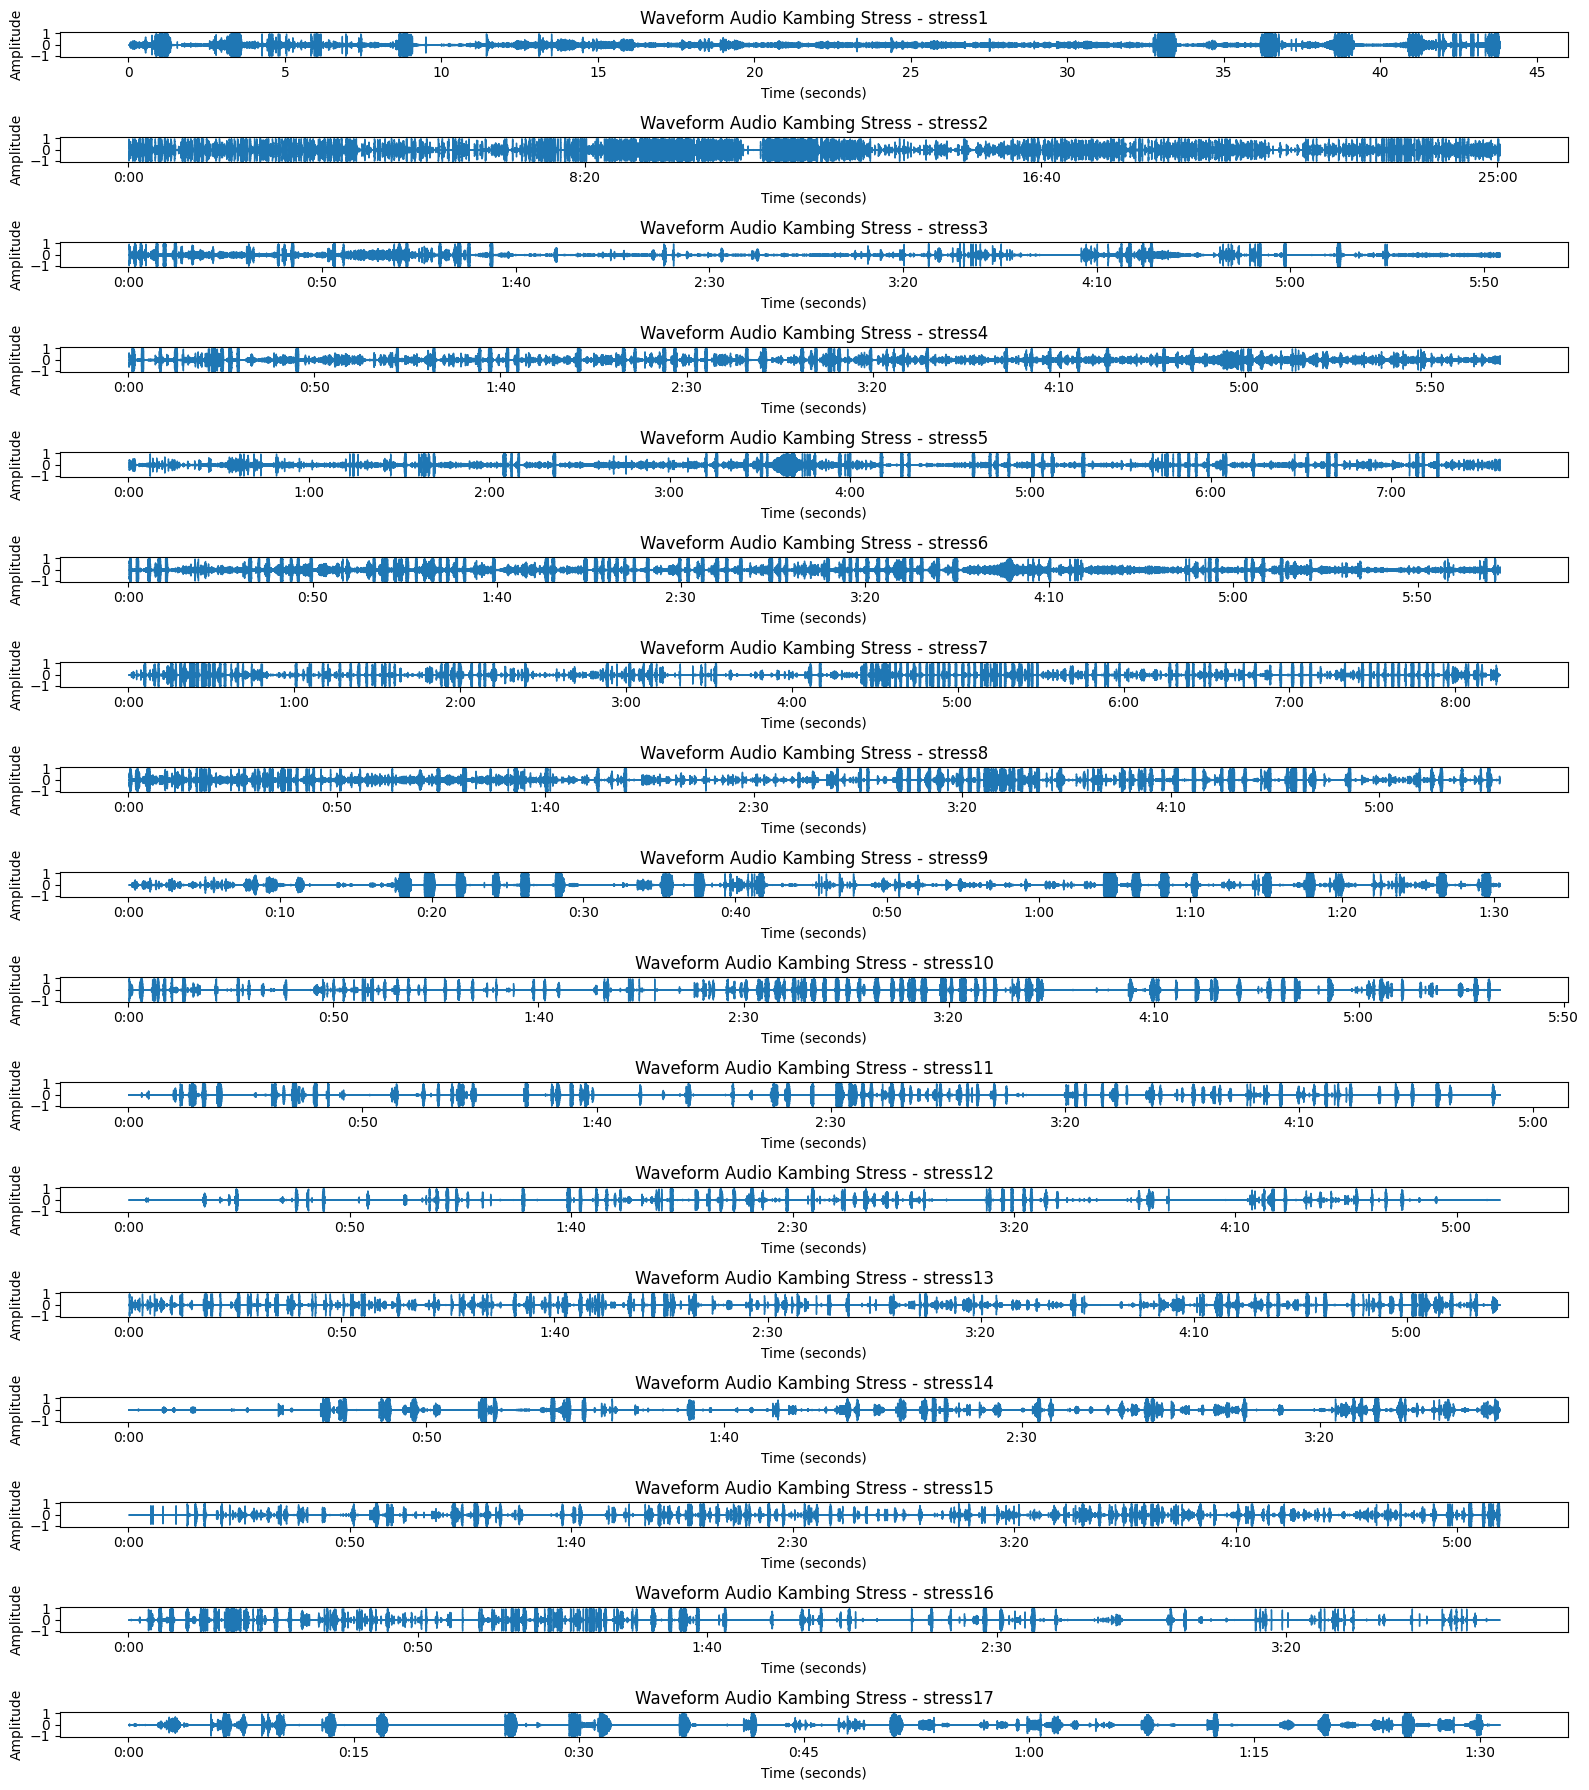

In [ ]:
plt.figure(figsize=(16, 18))

for idx, (key, y_stress) in enumerate(stress_audio_data.items(), start=1):
    sr_stress = stress_sample_rates[key]

    plt.subplot(17, 1, idx)
    librosa.display.waveshow(y_stress, sr=sr_stress)
    plt.title(f"Waveform Audio Kambing Stress - {key}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

- Garis tinggi → suara keras (kambing bersuara)

- Garis datar → diam / hening

Terlihat bahwa suara kambing tidak muncul terus-menerus

➡️ Kesimpulan:
Audio harus dipotong-potong, bukan dipakai utuh.

## Energi Suara (RMS Energy)

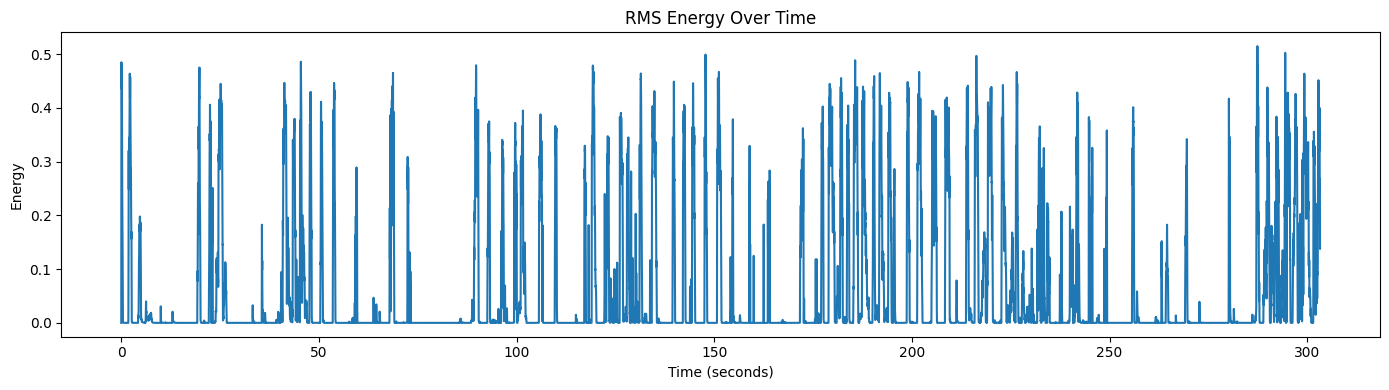

In [ ]:
hop_length = 512
frame_length = 2048

rms = librosa.feature.rms(
    y=y_normal,
    frame_length=frame_length,
    hop_length=hop_length
)[0]

times = librosa.frames_to_time(
    range(len(rms)),
    sr=sr_normal,
    hop_length=hop_length
)

plt.figure(figsize=(14,4))
plt.plot(times, rms)
plt.title("RMS Energy Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()

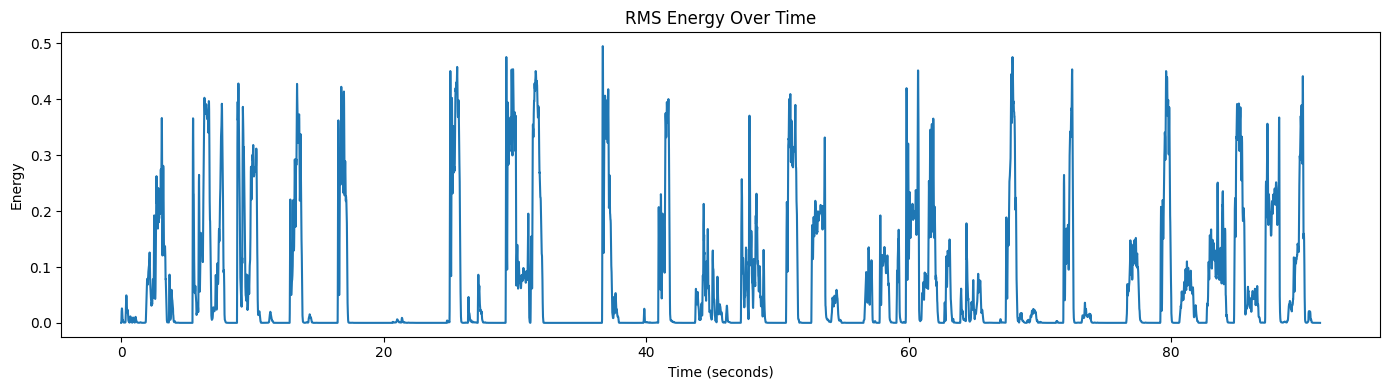

In [ ]:
hop_length = 512
frame_length = 2048

rms = librosa.feature.rms(
    y=y_stress,
    frame_length=frame_length,
    hop_length=hop_length
)[0]

times = librosa.frames_to_time(
    range(len(rms)),
    sr=sr_stress,
    hop_length=hop_length
)

plt.figure(figsize=(14,4))
plt.plot(times, rms)
plt.title("RMS Energy Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()

- Grafik ini menunjukkan kapan kambing bersuara

- Puncak tinggi → suara kambing

- Nilai rendah → diam atau noise

➡️ Dipakai untuk:

- Deteksi otomatis suara kambing

- Memotong audio panjang menjadi potongan kecil

## Zero Crossing Rate (Indikasi Noise)

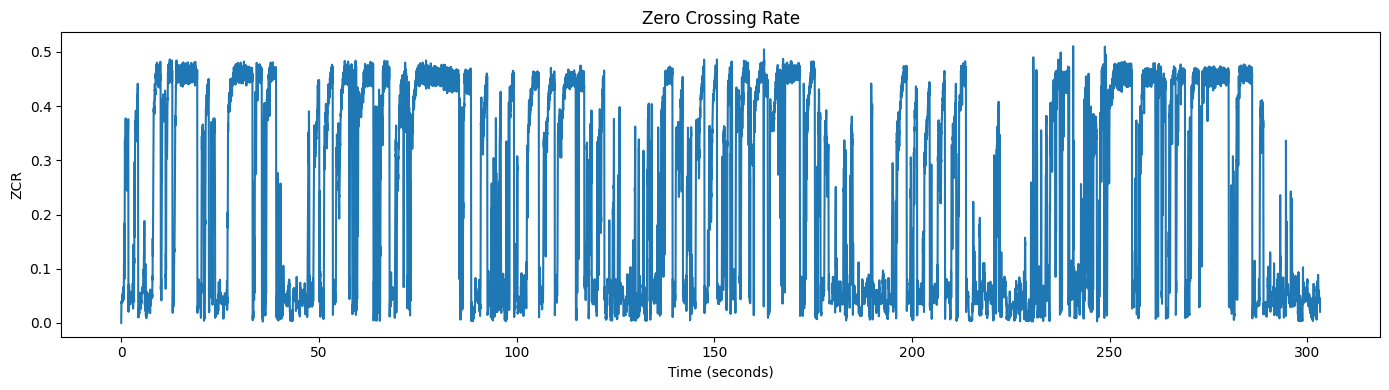

In [ ]:
zcr = librosa.feature.zero_crossing_rate(y_normal)[0]
times_zcr = librosa.frames_to_time(
    range(len(zcr)),
    sr=sr_normal,
    hop_length=512
)

plt.figure(figsize=(14,4))
plt.plot(times_zcr, zcr)
plt.title("Zero Crossing Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("ZCR")
plt.tight_layout()
plt.show()

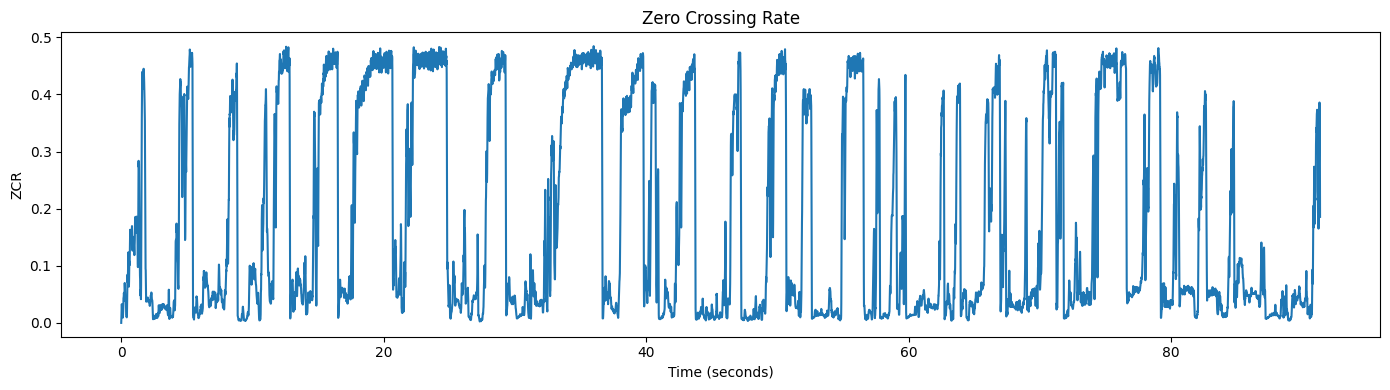

In [ ]:
zcr = librosa.feature.zero_crossing_rate(y_stress)[0]
times_zcr = librosa.frames_to_time(
    range(len(zcr)),
    sr=sr_stress,
    hop_length=512
)

plt.figure(figsize=(14,4))
plt.plot(times_zcr, zcr)
plt.title("Zero Crossing Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("ZCR")
plt.tight_layout()
plt.show()

📌 Penjelasan awam:

- Nilai tinggi → noise / suara manusia

- Nilai sedang → suara kambing alami

➡️ Bisa dipakai untuk filter segmen buruk

# Kesimpulan

- Audio kambing bersifat tidak kontinu

- Audio mentah harus dipotong (2–5 detik)

- Silence & noise harus dibuang